In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

from scipy.stats import hypergeom



In [ ]:
adata_path = large_data_dir + 'GBM_BC002_genotyped.h5ad'

adata = sc.read_h5ad(adata_path)
gf_utils.assign_genotypes(adata, min_counts=0, min_p=0.6)

adata.obs['cell_type'] = pd.read_csv('../output/GBM_cell_type_labels.txt', sep='\t', index_col=0).loc[adata.obs_names, 'cell_type']
adata.obs['tumor_normal_infercnv'] = pd.read_csv('../output/tumor_normal_labels_infercnv.txt', sep='\t', index_col=0).loc[adata.obs_names, 'infercnv']

variants = ['EGFR c.1889_1894delinsTAGGAT','EGFR c.685A>T','AXL c.1103G>A','CARD11 c.2149G>A','EGFR VIII']
adata.obsm['genotype_call'] = adata.obsm['genotype_call'][variants].copy()

adata.obsm['genotype_call']['type'] = adata.obs['tumor_normal_infercnv'].copy()


EGFR c.1889_1894delinsTAGGAT 2803 11192
EGFR c.685A>T 2318 11192
AXL c.1103G>A 486 11192
CARD11 c.2149G>A 104 11192
EGFR VIII 5744 11192


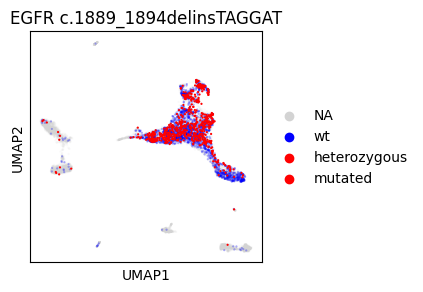

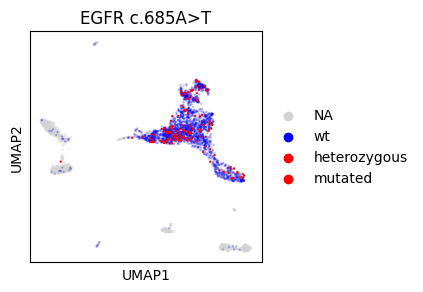

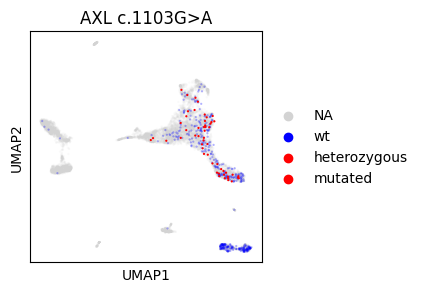

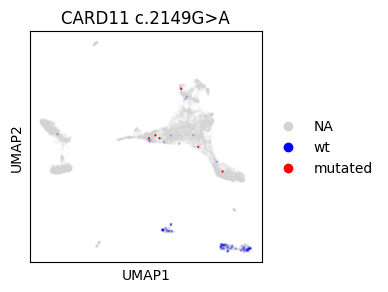

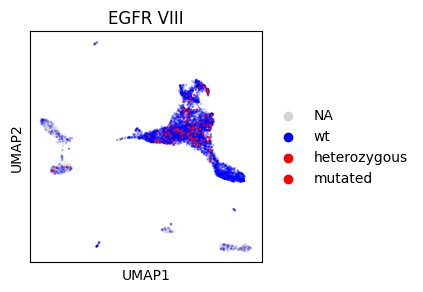

In [3]:
palette = {'NA':'lightgrey','wt':'blue','heterozygous':'red','mutated':'red'}

for variant in adata.obsm['genotype_call'].columns:
    if variant != 'type':
        adata.obs['genotype_call'] = adata.obsm['genotype_call'][variant].copy()
        adata.obs['genotype_call'] = adata.obs['genotype_call'].fillna('NA').copy()

        fig,ax = plt.subplots(figsize=(3,3))
        adata_na = adata[adata.obs['genotype_call'] == 'NA'].copy()
        adata_wt = adata[adata.obs['genotype_call'] == 'wt'].copy()
        adata_mut = adata[adata.obs['genotype_call'].isin(['heterozygous','mutated'])].copy()

        if len(adata_na) > 0:
            sc.pl.umap(adata_na, color = 'genotype_call', palette=palette, alpha=0.1, ax=ax, show=False, s=10)
        if len(adata_wt) > 0:
            sc.pl.umap(adata_wt, color = 'genotype_call', palette=palette, alpha=0.3, ax=ax, show=False, s=10)
        if len(adata_mut) > 0:
            sc.pl.umap(adata_mut, color = 'genotype_call', palette=palette, alpha=1, ax=ax, show=False, s=10, title=variant)

        ### print number of cells genotyped and number of cells in adata
        print(variant, len(adata_wt) + len(adata_mut), len(adata_wt) + len(adata_mut) + len(adata_na))
        plt.savefig(f'../plots/GBM_variant_{variant.replace(" ","").replace(".","").replace(">","").replace("<","")}.pdf')